# AB02 Oscar — Filter-based IK vs MoCap IK

Compare **filter-based IK** (Awinda/VQF from `mt_processed`, 6 Hz zero-phase LPF) against **MoCap IK** (OpenSim marker IK from processed awinda trials).

Useful for checking whether AB02's poor ID metrics come from IK mismatch or something downstream.

- **Filter IK**: `mt_processed/AB02_Oscar/ik/VQF/{speed}_{cond}.pkl`
- **MoCap IK**: `processed/AB02_Oscar/awinda/ik/{COND}_{speed}_ik.mot`
- **Sync**: hip+knee angle xcorr (z-scored, 5 s skip), same as `process_awinda.ipynb`
- **Eval**: 15 s post-sync transient trim, 6 Hz zero-phase LPF on both signals


In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import butter, sosfiltfilt

warnings.filterwarnings('ignore', message='.*NumPy.*')

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
IMU_IK_ROOT = Path('/home/metamobility3/Jinwoo/mt_processed')
IMU_IK_METHOD = 'VQF'
SUBJECT = 'AB02_Oscar'
MASS_KG = 71.1

CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]
DEFAULT_FS_HZ = 100.0
ALIGN_MAX_LAG_SEC = 30.0
XCORR_SKIP_SEC = 5.0
TRANSIENT_TRIM_SEC = 15.0
ANGLE_CUTOFF_HZ = 6.0
FILTER_ORDER = 4
IK_MIN_R2 = 0.7
IK_MAX_RMSE_DEG = 15.0
PREVIEW_FRAMES = 500

sys.path.insert(0, str(PROJECT_ROOT))
from dataset import IK_DOF_NAMES

IK_CHANNEL_IDX = [IK_DOF_NAMES.index(c) for c in CHANNELS]
XCORR_CHANNEL_IDX = [CHANNELS.index(c) for c in (
    'hip_flexion_r', 'knee_angle_r', 'hip_flexion_l', 'knee_angle_l'
)]

print(f'Subject: {SUBJECT} | mass={MASS_KG} kg')
print(f'Processed root: {PROCESSED_ROOT}')
print(f'IMU IK root: {IMU_IK_ROOT / SUBJECT / "ik" / IMU_IK_METHOD}')


Subject: AB02_Oscar | mass=71.1 kg
Processed root: /media/metamobility3/Samsung_T52/Results/processed
IMU IK root: /home/metamobility3/Jinwoo/mt_processed/AB02_Oscar/ik/VQF


In [2]:
def parse_opensim_table(path: Path) -> pd.DataFrame:
    with open(path) as f:
        header_end = next(i for i, line in enumerate(f) if line.strip().lower() == 'endheader')
    return pd.read_csv(path, sep=r'\s+', skiprows=header_end + 1).set_index('time')


def butter_lpf(x, fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ, order=FILTER_ORDER):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * fs_hz
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(x) < 4:
        return x.copy()
    sos = butter(order, cutoff_hz / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, x)


def lpf_mc(X, fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ):
    return np.column_stack([butter_lpf(X[:, c], fs_hz, cutoff_hz) for c in range(X.shape[1])])


def condition_to_pkl_stem(condition: str) -> str:
    cond, speed = condition.split('_', 1)
    return f'{speed}_{cond.lower()}'


def pkl_stem_to_condition(stem: str) -> str:
    speed, cond = stem.split('_', 1)
    return f'{cond.upper()}_{speed}'


def build_filter_ik_rad(imu_dict: dict) -> np.ndarray:
    n = len(next(iter(imu_dict.values())))
    pos_deg = np.zeros((n, len(IK_DOF_NAMES)), dtype=np.float64)
    key_map = {
        'hip_flexion_r': 'hip_flexion_r', 'knee_angle_r': 'knee_flexion_r', 'ankle_angle_r': 'ankle_flexion_r',
        'hip_flexion_l': 'hip_flexion_l', 'knee_angle_l': 'knee_flexion_l', 'ankle_angle_l': 'ankle_flexion_l',
    }
    sign_map = {'knee_angle_r': -1.0, 'knee_angle_l': -1.0}
    for ik_name, pkl_name in key_map.items():
        idx = IK_DOF_NAMES.index(ik_name)
        pos_deg[:, idx] = sign_map.get(ik_name, 1.0) * np.asarray(imu_dict[pkl_name], dtype=np.float64)
    return np.deg2rad(pos_deg)


def build_mocap_ik_rad(ik_df: pd.DataFrame) -> np.ndarray:
    pos_deg = np.full((len(ik_df), len(IK_DOF_NAMES)), np.nan)
    for j, name in enumerate(IK_DOF_NAMES):
        if name in ik_df.columns:
            pos_deg[:, j] = ik_df[name].to_numpy(dtype=np.float64)
    return np.deg2rad(pos_deg)


def clip_lag(lag, max_lag_samples):
    clipped = False
    if lag > max_lag_samples:
        lag, clipped = max_lag_samples, True
    elif lag < -max_lag_samples:
        lag, clipped = -max_lag_samples, True
    return int(lag), clipped


def _zscore_1d(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.isfinite(x)
    if m.sum() < 2:
        return np.zeros_like(x)
    mu, sd = float(np.nanmean(x[m])), float(np.nanstd(x[m]))
    if sd < 1e-9:
        return np.zeros_like(x)
    out = (x - mu) / sd
    out[~m] = 0.0
    return out


def estimate_lag_from_angle_xcorr(filter_rad, mocap_rad, fs_hz, max_lag_samples):
    filter_f = lpf_mc(filter_rad[:, IK_CHANNEL_IDX], fs_hz)
    mocap_f = lpf_mc(mocap_rad[:, IK_CHANNEL_IDX], fs_hz)
    skip = int(round(XCORR_SKIP_SEC * fs_hz))
    best_lag, best_score = 0, -np.inf
    for lag in range(-max_lag_samples, max_lag_samples + 1):
        start_f, start_m = max(lag, 0), max(-lag, 0)
        nn = min(len(filter_f) - start_f, len(mocap_f) - start_m) - skip
        if nn < int(round(2.0 * fs_hz)):
            continue
        seg_f = filter_f[start_f + skip:start_f + skip + nn]
        seg_m = mocap_f[start_m + skip:start_m + skip + nn]
        score = sum(
            float(np.dot(_zscore_1d(seg_f[:, c]), _zscore_1d(seg_m[:, c])) / nn)
            for c in XCORR_CHANNEL_IDX
        )
        if score > best_score:
            best_score, best_lag = score, lag
    lag, clipped = clip_lag(best_lag, max_lag_samples)
    return lag, {'xcorr_score': float(best_score), 'lag_clipped': clipped}


def rmse_r2_deg(y_pred, y_ref):
    m = np.isfinite(y_pred) & np.isfinite(y_ref)
    if m.sum() < 2:
        return np.nan, np.nan
    e = y_pred[m] - y_ref[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    r2 = float(np.corrcoef(y_pred[m], y_ref[m])[0, 1] ** 2)
    return rmse, r2


def resolve_trial_paths(condition: str):
    pkl_path = IMU_IK_ROOT / SUBJECT / 'ik' / IMU_IK_METHOD / f'{condition_to_pkl_stem(condition)}.pkl'
    mocap_path = PROCESSED_ROOT / SUBJECT / 'awinda' / 'ik' / f'{condition}_ik.mot'
    return pkl_path, mocap_path


def list_ab02_trials():
    ik_dir = IMU_IK_ROOT / SUBJECT / 'ik' / IMU_IK_METHOD
    rows = []
    for pkl_path in sorted(ik_dir.glob('*.pkl')):
        cond = pkl_stem_to_condition(pkl_path.stem)
        mocap_path = PROCESSED_ROOT / SUBJECT / 'awinda' / 'ik' / f'{cond}_ik.mot'
        rows.append({
            'condition': cond,
            'pkl_path': pkl_path,
            'mocap_path': mocap_path,
            'ready': pkl_path.exists() and mocap_path.exists(),
        })
    return pd.DataFrame(rows)

print('Helpers ready.')


Helpers ready.


In [3]:
trial_inventory = list_ab02_trials()
print(f'Found {len(trial_inventory)} filter-IK pkl files for {SUBJECT}')
display(trial_inventory)

if not trial_inventory['ready'].all():
    missing = trial_inventory[~trial_inventory['ready']]
    raise FileNotFoundError('Missing MoCap IK or filter IK files:\n' + missing.to_string())

fs_hz = DEFAULT_FS_HZ
max_lag_samples = int(round(ALIGN_MAX_LAG_SEC * fs_hz))
trim_n = int(round(TRANSIENT_TRIM_SEC * fs_hz))

TRIAL_DATA = {}
detail_rows = []
summary_rows = []
errors = []

for _, row in trial_inventory.iterrows():
    cond = row['condition']
    trial_key = f'{SUBJECT}::{cond}'
    try:
        filter_rad = build_filter_ik_rad(pickle.load(open(row['pkl_path'], 'rb')))
        mocap_df = parse_opensim_table(row['mocap_path'])
        t_mocap = mocap_df.index.to_numpy(dtype=np.float64)
        mocap_rad = build_mocap_ik_rad(mocap_df)

        lag, sync_dbg = estimate_lag_from_angle_xcorr(filter_rad, mocap_rad, fs_hz, max_lag_samples)
        filter_6 = filter_rad[:, IK_CHANNEL_IDX]
        mocap_6 = mocap_rad[:, IK_CHANNEL_IDX]

        start_f, start_m = max(lag, 0), max(-lag, 0)
        n_sync = min(len(filter_6) - start_f, len(mocap_6) - start_m)
        if n_sync <= trim_n:
            raise RuntimeError(f'Not enough samples after {TRANSIENT_TRIM_SEC}s trim: {n_sync}')

        filter_sync_f = lpf_mc(filter_6[start_f:start_f + n_sync], fs_hz)
        mocap_sync_f = lpf_mc(mocap_6[start_m:start_m + n_sync], fs_hz)
        filter_sync_raw = filter_6[start_f:start_f + n_sync]
        mocap_sync_raw = mocap_6[start_m:start_m + n_sync]

        filter_eval = np.rad2deg(filter_sync_f[trim_n:])
        mocap_eval = np.rad2deg(mocap_sync_f[trim_n:])
        filter_raw_eval = np.rad2deg(filter_sync_raw[trim_n:])
        mocap_raw_eval = np.rad2deg(mocap_sync_raw[trim_n:])
        t_eval = t_mocap[start_m + trim_n:start_m + n_sync]

        metrics = []
        for c, channel in enumerate(CHANNELS):
            rmse, r2 = rmse_r2_deg(filter_eval[:, c], mocap_eval[:, c])
            metrics.append({'channel': channel, 'rmse_deg': rmse, 'r2': r2})
            detail_rows.append({
                'trial': trial_key, 'condition': cond, 'channel': channel,
                'rmse_deg': rmse, 'r2': r2,
            })

        n_pre = min(PREVIEW_FRAMES, n_sync)
        TRIAL_DATA[trial_key] = {
            'condition': cond,
            'lag_samples': lag,
            'lag_sec': lag / fs_hz,
            'xcorr_score': sync_dbg['xcorr_score'],
            'lag_clipped': sync_dbg['lag_clipped'],
            't': t_eval,
            'filter_deg': filter_eval,
            'mocap_deg': mocap_eval,
            'filter_raw_deg': filter_raw_eval,
            'mocap_raw_deg': mocap_raw_eval,
            'metrics': metrics,
                    'sync_preview': {
                        't_mocap': t_mocap[:n_pre] - t_mocap[0],
                        't_filter': np.arange(n_pre) / fs_hz,
                        'mocap_hip_deg': np.rad2deg(mocap_sync_f[:n_pre, 0]),
                        'filter_hip_deg': np.rad2deg(filter_sync_f[:n_pre, 0]),
                        'mocap_hip_raw_deg': np.rad2deg(mocap_sync_raw[:n_pre, 0]),
                        'filter_hip_raw_deg': np.rad2deg(filter_sync_raw[:n_pre, 0]),
                    },
        }
        summary_rows.append({
            'trial': trial_key,
            'condition': cond,
            'lag_samples': lag,
            'lag_sec': lag / fs_hz,
            'xcorr_score': sync_dbg['xcorr_score'],
            'mean_rmse_deg': float(np.nanmean([m['rmse_deg'] for m in metrics])),
            'mean_r2': float(np.nanmean([m['r2'] for m in metrics])),
            'n': len(filter_eval),
        })
    except Exception as exc:
        errors.append(f'{trial_key}: {exc}')

summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(detail_rows)

if errors:
    print('Warnings:')
    for msg in errors:
        print(f'  [WARN] {msg}')
if summary_df.empty:
    raise RuntimeError('No IK comparisons computed.')

summary_df['ik_ok'] = (summary_df['mean_r2'] >= IK_MIN_R2) & (summary_df['mean_rmse_deg'] <= IK_MAX_RMSE_DEG)

print(
    f'\nFilter IK vs MoCap IK ({TRANSIENT_TRIM_SEC:.0f}s post-sync trim, {ANGLE_CUTOFF_HZ:g} Hz zero-phase LPF)\n'
    f'  QC: mean R² >= {IK_MIN_R2} and mean RMSE <= {IK_MAX_RMSE_DEG} deg\n'
    f'  trials OK: {summary_df["ik_ok"].sum()} / {len(summary_df)}'
)
display(summary_df.sort_values('condition').reset_index(drop=True))
print('\nPer-joint mean across trials:')
display(detail_df.groupby('channel')[['rmse_deg', 'r2']].mean())


Found 5 filter-IK pkl files for AB02_Oscar


,condition,pkl_path,mocap_path,ready
0,LG_0p8mps,/home/metamobility3/Jinwoo/mt_processed/AB02_O...,/media/metamobility3/Samsung_T52/Results/proce...,True
1,RA_0p8mps,/home/metamobility3/Jinwoo/mt_processed/AB02_O...,/media/metamobility3/Samsung_T52/Results/proce...,True
2,RD_0p8mps,/home/metamobility3/Jinwoo/mt_processed/AB02_O...,/media/metamobility3/Samsung_T52/Results/proce...,True
3,LG_1p2mps,/home/metamobility3/Jinwoo/mt_processed/AB02_O...,/media/metamobility3/Samsung_T52/Results/proce...,True
4,LG_1p6mps,/home/metamobility3/Jinwoo/mt_processed/AB02_O...,/media/metamobility3/Samsung_T52/Results/proce...,True



Filter IK vs MoCap IK (15s post-sync trim, 6 Hz zero-phase LPF)
  QC: mean R² >= 0.7 and mean RMSE <= 15.0 deg
  trials OK: 5 / 5


,trial,condition,lag_samples,lag_sec,xcorr_score,mean_rmse_deg,mean_r2,n,ik_ok
0,AB02_Oscar::LG_0p8mps,LG_0p8mps,1240,12.40,3.933775,10.413839,0.904871,6500,True
1,AB02_Oscar::LG_1p2mps,LG_1p2mps,288,2.88,3.943511,10.002949,0.937695,6500,True
2,AB02_Oscar::LG_1p6mps,LG_1p6mps,259,2.59,3.946060,9.192861,0.936450,6500,True
3,AB02_Oscar::RA_0p8mps,RA_0p8mps,294,2.94,3.969190,7.488409,0.958952,6500,True
4,AB02_Oscar::RD_0p8mps,RD_0p8mps,759,7.59,3.906042,9.851908,0.874641,6500,True



Per-joint mean across trials:


,rmse_deg,r2
channel,,
ankle_angle_l,6.163221,0.859737
ankle_angle_r,13.621438,0.794249
hip_flexion_l,5.982683,0.952487
hip_flexion_r,12.306288,0.953426
knee_angle_l,4.659196,0.996088
knee_angle_r,13.607133,0.979143


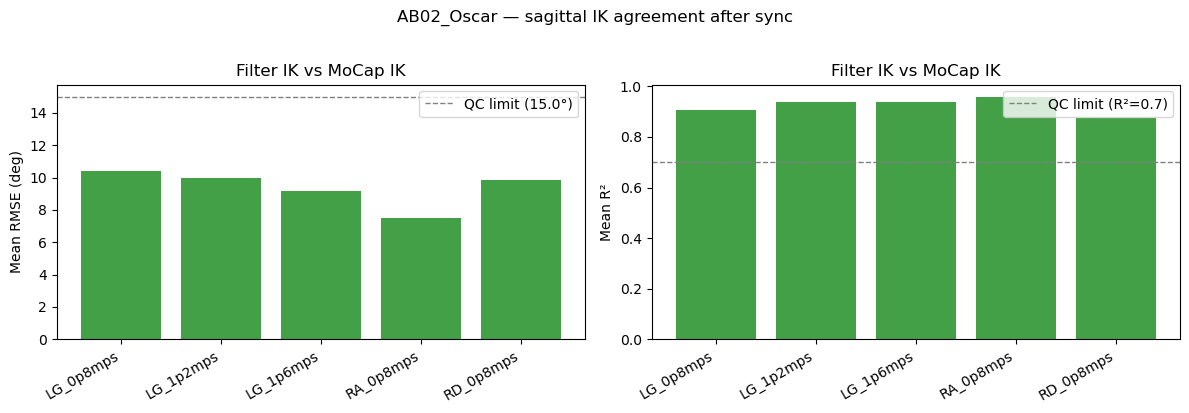

In [4]:
# Bar summary: mean RMSE / R² per trial
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
order = summary_df.sort_values('condition')['condition']
x = np.arange(len(order))
vals_rmse = summary_df.set_index('condition').loc[order, 'mean_rmse_deg']
vals_r2 = summary_df.set_index('condition').loc[order, 'mean_r2']
colors = ['#43a047' if ok else '#e53935' for ok in summary_df.set_index('condition').loc[order, 'ik_ok']]

axs[0].bar(x, vals_rmse, color=colors)
axs[0].axhline(IK_MAX_RMSE_DEG, color='gray', ls='--', lw=1, label=f'QC limit ({IK_MAX_RMSE_DEG}°)')
axs[0].set_xticks(x, order, rotation=30, ha='right')
axs[0].set_ylabel('Mean RMSE (deg)')
axs[0].set_title('Filter IK vs MoCap IK')
axs[0].legend()

axs[1].bar(x, vals_r2, color=colors)
axs[1].axhline(IK_MIN_R2, color='gray', ls='--', lw=1, label=f'QC limit (R²={IK_MIN_R2})')
axs[1].set_xticks(x, order, rotation=30, ha='right')
axs[1].set_ylabel('Mean R²')
axs[1].set_title('Filter IK vs MoCap IK')
axs[1].legend()
fig.suptitle(f'{SUBJECT} — sagittal IK agreement after sync', y=1.02)
fig.tight_layout()
plt.show()


In [5]:
names = ['Hip R', 'Knee R', 'Ankle R', 'Hip L', 'Knee L', 'Ankle L']
trial_options = sorted(TRIAL_DATA)

trial_dd = widgets.Dropdown(options=trial_options, description='Trial:')
show_raw_cb = widgets.Checkbox(value=False, description='Show unfiltered (pre-LPF)')
time_slider = widgets.FloatRangeSlider(
    description='Time (s):', continuous_update=False, layout=widgets.Layout(width='700px')
)
sync_out = widgets.Output()
ik_out = widgets.Output()


def _trial_time_rel(trial_key):
    t = np.asarray(TRIAL_DATA[trial_key]['t'], dtype=np.float64)
    return t - t[0]


def _set_slider(trial_key):
    t_rel = _trial_time_rel(trial_key)
    tmin, tmax = float(t_rel[0]), float(t_rel[-1])
    step = max((tmax - tmin) / 500, 1e-3)
    with time_slider.hold_sync():
        time_slider.min = tmin
        time_slider.max = tmax
        time_slider.step = step
        time_slider.value = (tmin, tmax)


def _draw_sync(trial_key):
    d = TRIAL_DATA[trial_key]
    sp = d['sync_preview']
    lag = d['lag_samples']
    fs = DEFAULT_FS_HZ

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sp['t_mocap'], sp['mocap_hip_deg'], label='MoCap hip R (LPF)', color='#1e88e5', lw=1.8)
    ax.plot(sp['t_filter'], sp['filter_hip_deg'], label='Filter hip R (LPF)', color='#43a047', lw=1.4)
    sp_idx = max(lag, 0)
    n_shift = min(len(sp['t_mocap']), len(sp['filter_hip_deg']) - sp_idx)
    if n_shift > 0:
        ax.plot(
            sp['t_mocap'][:n_shift], sp['filter_hip_deg'][sp_idx:sp_idx + n_shift],
            label=f'Filter shifted ({d["lag_sec"]:+.2f}s)', color='#1e88e5', lw=1.2, ls='--', alpha=0.85,
        )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Hip flexion R (deg)')
    ax.set_title(
        f"{trial_key} | angle xcorr sync | lag={lag:+d} samples ({d['lag_sec']:+.3f}s) | score={d['xcorr_score']:.3f}"
    )
    ax.legend()
    fig.tight_layout()
    with sync_out:
        sync_out.clear_output(wait=True)
        plt.show()


def _draw_ik(trial_key, t_window, show_raw=False):
    d = TRIAL_DATA[trial_key]
    if show_raw:
        y_filter = np.asarray(d['filter_raw_deg'], dtype=np.float64)
        y_mocap = np.asarray(d['mocap_raw_deg'], dtype=np.float64)
        filt_label, mocap_label = 'Filter IK (raw)', 'MoCap IK (raw)'
    else:
        y_filter = np.asarray(d['filter_deg'], dtype=np.float64)
        y_mocap = np.asarray(d['mocap_deg'], dtype=np.float64)
        filt_label, mocap_label = 'Filter IK (6 Hz LPF)', 'MoCap IK (6 Hz LPF)'

    t = _trial_time_rel(trial_key)
    n = min(len(t), len(y_filter), len(y_mocap))
    t, y_filter, y_mocap = t[:n], y_filter[:n], y_mocap[:n]
    t0, t1 = t_window

    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for c, ax in enumerate(axs.reshape(-1)):
        m = d['metrics'][c]
        ax.plot(t, y_mocap[:, c], label=mocap_label, color='#1e88e5', lw=1.8)
        ax.plot(t, y_filter[:, c], label=filt_label, color='#e53935', lw=1.4, ls='--')
        ax.set_title(f"{names[c]} | RMSE={m['rmse_deg']:.2f}°, R²={m['r2']:.3f}")
        ax.set_xlim(t0, t1)
        ax.set_ylabel('Angle (deg)')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        if c == 0:
            ax.legend(fontsize=8)
    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time (s)')
    ik_ok = summary_df.set_index('trial').loc[trial_key, 'ik_ok']
    badge = 'IK OK' if ik_ok else 'IK flagged'
    fig.suptitle(
        f"{trial_key} | {badge} | synced + {TRANSIENT_TRIM_SEC:.0f}s trim | lag={d['lag_sec']:+.3f}s",
        fontsize=12,
    )
    fig.tight_layout()
    with ik_out:
        ik_out.clear_output(wait=True)
        plt.show()


def _redraw(*_):
    tk = trial_dd.value
    _draw_sync(tk)
    _draw_ik(tk, time_slider.value, show_raw=show_raw_cb.value)


def _on_trial(change):
    _set_slider(change['new'])
    _redraw()

trial_dd.observe(_on_trial, names='value')
time_slider.observe(_redraw, names='value')
show_raw_cb.observe(_redraw, names='value')
_set_slider(trial_dd.value)

display(widgets.VBox([
    widgets.HBox([trial_dd, show_raw_cb]),
    time_slider,
    widgets.HTML('<b>Sync preview (hip flexion R, first 5 s)</b>'),
    sync_out,
    widgets.HTML('<b>Filter IK vs MoCap IK (eval window)</b>'),
    ik_out,
]))
_redraw()


In [6]:
# Cross-check against process_awinda cache lags (if available)
cache_path = PROJECT_ROOT / 'analysis' / 'cache' / 'process_awinda.npz'
if cache_path.exists():
    cache = np.load(str(cache_path), allow_pickle=True)
    rows = []
    for trial_key in sorted(TRIAL_DATA):
        cond = TRIAL_DATA[trial_key]['condition']
        cache_key = f'{SUBJECT}::{cond}'
        if cache_key not in [str(k) for k in cache['trial_keys']]:
            rows.append({'condition': cond, 'this_notebook_lag': TRIAL_DATA[trial_key]['lag_samples'], 'cache_lag': np.nan, 'delta': np.nan})
            continue
        pref = cache_key.replace('::', '__')
        meta = cache[f'{pref}__meta']
        cache_lag = int(meta[3])
        this_lag = TRIAL_DATA[trial_key]['lag_samples']
        rows.append({'condition': cond, 'this_notebook_lag': this_lag, 'cache_lag': cache_lag, 'delta': this_lag - cache_lag})
    cmp_df = pd.DataFrame(rows)
    print('Lag comparison vs process_awinda cache:')
    display(cmp_df)
else:
    print(f'No cache at {cache_path} — skip lag cross-check.')


Lag comparison vs process_awinda cache:


,condition,this_notebook_lag,cache_lag,delta
0,LG_0p8mps,1240,1240,0
1,LG_1p2mps,288,288,0
2,LG_1p6mps,259,259,0
3,RA_0p8mps,294,295,-1
4,RD_0p8mps,759,759,0
